In [2]:
import pandas as pd
df = pd.read_csv(r"C:\Users\Manaswini\Downloads\project\nlp\train.csv")

In [3]:
df.head()

,count,hate_speech_count,offensive_language_count,neither_count,class,tweet
0,3,0,0,3,2,!!! RT @mayasolovely: As a woman you shouldn't...
1,3,0,3,0,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,3,0,3,0,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,3,0,2,1,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,6,0,6,0,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...


In [4]:
print("Shape:", df.shape)
df.info()
df.isnull().sum()

Shape: (24783, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24783 entries, 0 to 24782
Data columns (total 6 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   count                     24783 non-null  int64 
 1   hate_speech_count         24783 non-null  int64 
 2   offensive_language_count  24783 non-null  int64 
 3   neither_count             24783 non-null  int64 
 4   class                     24783 non-null  int64 
 5   tweet                     24783 non-null  object
dtypes: int64(5), object(1)
memory usage: 1.1+ MB


count                       0
hate_speech_count           0
offensive_language_count    0
neither_count               0
class                       0
tweet                       0
dtype: int64

In [5]:
df['class'].value_counts()

class
1    19190
2     4163
0     1430
Name: count, dtype: int64

In [6]:
df['class'].value_counts(normalize=True) * 100

class
1    77.432111
2    16.797805
0     5.770084
Name: proportion, dtype: float64

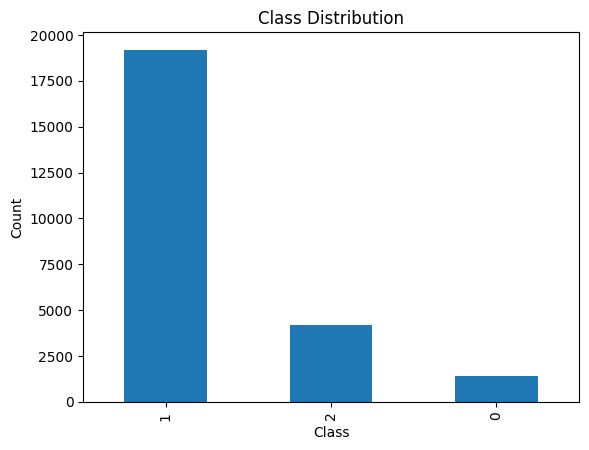

In [7]:
import matplotlib.pyplot as plt
df['class'].value_counts().plot(kind='bar')
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [8]:
df.groupby('class')[['hate_speech_count','offensive_language_count','neither_count']].mean()

,hate_speech_count,offensive_language_count,neither_count
class,,,
0,2.256643,0.755944,0.095804
1,0.180459,3.003544,0.084888
2,0.062935,0.264233,2.845544


In [9]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df['clean_tweet'] = df['tweet'].apply(clean_text)
df[['tweet', 'clean_tweet']].head()

,tweet,clean_tweet
0,!!! RT @mayasolovely: As a woman you shouldn't...,rt as a woman you shouldnt complain about clea...
1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...,rt boy dats coldtyga dwn bad for cuffin dat ho...
2,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...,rt dawg rt you ever fuck a bitch and she start...
3,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...,rt she look like a tranny
4,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...,rt the shit you hear about me might be true or...


In [10]:
df['tweet_length'] = df['clean_tweet'].apply(len)

df['tweet_length'].describe()

count    24783.000000
mean        63.796110
std         33.357477
min          0.000000
25%         37.000000
50%         59.000000
75%         90.000000
max        142.000000
Name: tweet_length, dtype: float64

In [11]:
(df['clean_tweet'] == '').sum()

np.int64(2)

In [12]:
df = df[df['clean_tweet'] != '']
df.shape

(24781, 8)

In [13]:
from sklearn.feature_extraction.text import CountVectorizer

vec = CountVectorizer(stop_words='english', max_features=20)
X = vec.fit_transform(df['clean_tweet'])

word_freq = X.sum(axis=0).A1
words = vec.get_feature_names_out()

freq_df = pd.DataFrame({'word': words, 'count': word_freq})
freq_df = freq_df.sort_values(by='count', ascending=False)

freq_df

,word,count
3,bitch,8237
17,rt,7634
4,bitches,3084
13,like,2771
9,hoes,2369
16,pussy,2108
10,im,2090
8,hoe,1910
5,dont,1781
2,ass,1570


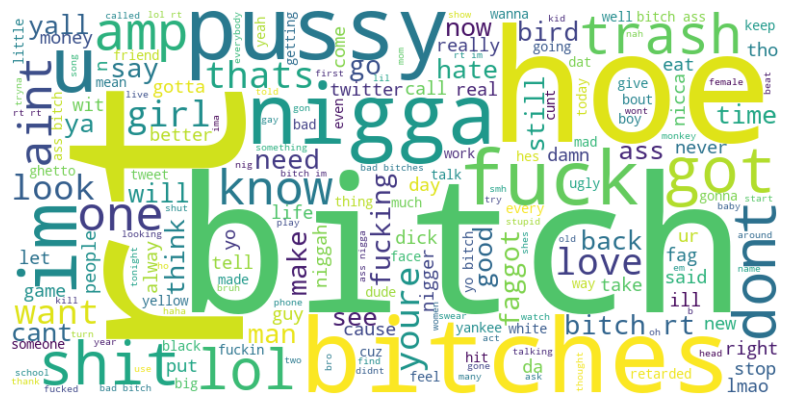

In [14]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = " ".join(df['clean_tweet'])

wc = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.show()

In [16]:
import re

def clean_text(text):
    text = str(text)

    text = re.sub(r"&\w+;", "", text)

    text = re.sub(r"@\w+", "user", text)

    text = re.sub(r"http\S+|www\S+", "", text)

    return text

df['clean_step1'] = df['tweet'].apply(clean_text)

df[['tweet', 'clean_step1']].head()

,tweet,clean_step1
0,!!! RT @mayasolovely: As a woman you shouldn't...,!!! RT user: As a woman you shouldn't complain...
1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...,!!!!! RT user: boy dats cold...tyga dwn bad fo...
2,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...,!!!!!!! RT user Dawg!!!! RT user: You ever fuc...
3,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...,!!!!!!!!! RT user: user she look like a tranny
4,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...,!!!!!!!!!!!!! RT user: The shit you hear about...


In [17]:
def clean_text_2(text):
    text = str(text)

    text = re.sub(r"[!\"'.,;:?()\-]", " ", text)

    text = re.sub(r"\s+", " ", text).strip()

    return text

df['clean_step2'] = df['clean_step1'].apply(clean_text_2)

df[['clean_step1', 'clean_step2']].head()

,clean_step1,clean_step2
0,!!! RT user: As a woman you shouldn't complain...,RT user As a woman you shouldn t complain abou...
1,!!!!! RT user: boy dats cold...tyga dwn bad fo...,RT user boy dats cold tyga dwn bad for cuffin ...
2,!!!!!!! RT user Dawg!!!! RT user: You ever fuc...,RT user Dawg RT user You ever fuck a bitch and...
3,!!!!!!!!! RT user: user she look like a tranny,RT user user she look like a tranny
4,!!!!!!!!!!!!! RT user: The shit you hear about...,RT user The shit you hear about me might be tr...


In [18]:
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def final_clean(text):
    text = text.lower()
    
    text = re.sub(r"\d+", "", text)
    
    text = re.sub(r"\s+", " ", text).strip()
    
    words = text.split()
    words = [w for w in words if w not in stop_words]
    
    return " ".join(words)

df['processed_text'] = df['clean_step2'].apply(final_clean)

df[['clean_step2', 'processed_text']].head()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Manaswini\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,clean_step2,processed_text
0,RT user As a woman you shouldn t complain abou...,rt user woman complain cleaning house man alwa...
1,RT user boy dats cold tyga dwn bad for cuffin ...,rt user boy dats cold tyga dwn bad cuffin dat ...
2,RT user Dawg RT user You ever fuck a bitch and...,rt user dawg rt user ever fuck bitch start cry...
3,RT user user she look like a tranny,rt user user look like tranny
4,RT user The shit you hear about me might be tr...,rt user shit hear might true might faker bitch...


In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df['processed_text'])
y = df['class']

print("Shape of X:", X.shape)

Shape of X: (24781, 5000)


In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(X_train.shape, X_test.shape)

(19824, 5000) (4957, 5000)


In [22]:
from sklearn.feature_extraction.text import CountVectorizer

# separate classes
toxic_text = df[df['class'] != 2]['processed_text']   # hate + offensive
neutral_text = df[df['class'] == 2]['processed_text']

# vectorize
vec = CountVectorizer(max_features=1000)
toxic_matrix = vec.fit_transform(toxic_text)

toxic_words = set(vec.get_feature_names_out())

# neutral words
vec2 = CountVectorizer(max_features=300)
neutral_matrix = vec2.fit_transform(neutral_text)

neutral_words = set(vec2.get_feature_names_out())

# final toxic words = toxic - neutral
final_toxic_words = toxic_words - neutral_words

print("Number of toxic words:", len(final_toxic_words))
list(final_toxic_words)[:20]

Number of toxic words: 751


['cuh',
 'working',
 'swear',
 'ol',
 'face',
 'lil',
 'chick',
 'cus',
 'mexican',
 'water',
 'baddest',
 'fall',
 'cops',
 'tweets',
 'understand',
 'beer',
 'thinkin',
 'stuck',
 'chill',
 'cop']

In [24]:
import pickle

file_path = r"C:\Users\Manaswini\Downloads\toxic_words.pkl"

with open(file_path, "wb") as f:
    pickle.dump(final_toxic_words, f)

print("Saved to Downloads!")

Saved to Downloads!


In [25]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [26]:
y_pred = model.predict(X_test)

In [27]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9047811176114585

Classification Report:
               precision    recall  f1-score   support

           0       0.60      0.16      0.25       286
           1       0.92      0.97      0.94      3838
           2       0.87      0.86      0.86       833

    accuracy                           0.90      4957
   macro avg       0.79      0.66      0.68      4957
weighted avg       0.89      0.90      0.89      4957



In [28]:
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [29]:
y_pred_bal = model.predict(X_test)

In [30]:
print("Accuracy:", accuracy_score(y_test, y_pred_bal))
print("\nClassification Report:\n", classification_report(y_test, y_pred_bal))

Accuracy: 0.8491022796045996

Classification Report:
               precision    recall  f1-score   support

           0       0.29      0.60      0.39       286
           1       0.97      0.85      0.90      3838
           2       0.78      0.95      0.85       833

    accuracy                           0.85      4957
   macro avg       0.68      0.80      0.72      4957
weighted avg       0.90      0.85      0.87      4957



In [31]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC()
svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)

In [32]:
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm))

Accuracy: 0.8975186604801291

Classification Report:
               precision    recall  f1-score   support

           0       0.52      0.23      0.32       286
           1       0.92      0.96      0.94      3838
           2       0.84      0.85      0.85       833

    accuracy                           0.90      4957
   macro avg       0.76      0.68      0.70      4957
weighted avg       0.88      0.90      0.89      4957



In [33]:
import pandas as pd

results = {
    "Model": ["Logistic Regression", "LR (Balanced)", "SVM"],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_bal),
        accuracy_score(y_test, y_pred_svm)
    ],
    "Hate Recall (Class 0)": [
        0.16,   # from your output
        0.60,
        0.23
    ]
}

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Hate Recall (Class 0)
0,Logistic Regression,0.904781,0.16
1,LR (Balanced),0.849102,0.60
2,SVM,0.897519,0.23


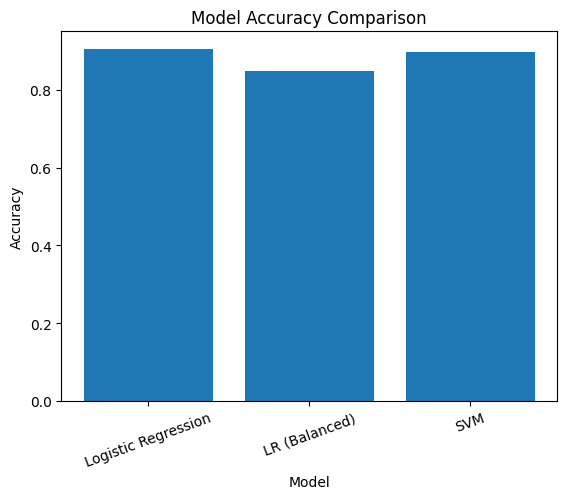

In [34]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(results_df["Model"], results_df["Accuracy"])
plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.xticks(rotation=20)
plt.show()

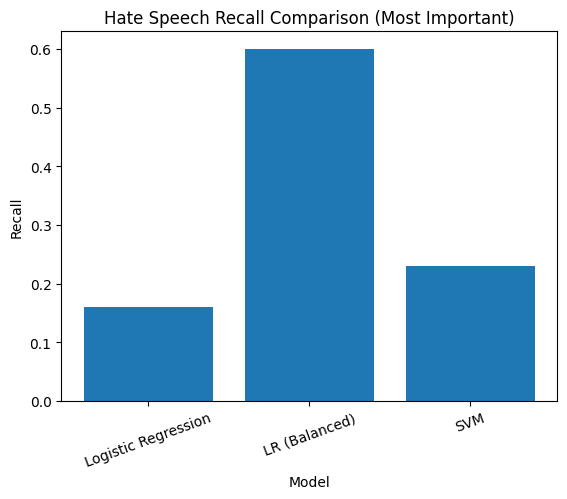

In [35]:
plt.figure()
plt.bar(results_df["Model"], results_df["Hate Recall (Class 0)"])
plt.title("Hate Speech Recall Comparison (Most Important)")
plt.xlabel("Model")
plt.ylabel("Recall")
plt.xticks(rotation=20)
plt.show()

In [36]:
import pickle

model_path = r"C:\Users\Manaswini\Downloads\hate_speech_model.pkl"

with open(model_path, "wb") as f:
    pickle.dump(model, f)

print("Model saved to Downloads!")

Model saved to Downloads!


In [37]:
tfidf_path = r"C:\Users\Manaswini\Downloads\tfidf_vectorizer.pkl"

with open(tfidf_path, "wb") as f:
    pickle.dump(tfidf, f)

print("Vectorizer saved!")

Vectorizer saved!
